In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import json

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
base_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

aug_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

resize_transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_train = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=None
)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_subset, val_subset = random_split(full_train, [train_size, val_size],
                                        generator=torch.Generator().manual_seed(SEED))

def make_loaders(transform_train, transform_val, batch_size=128):
    train_dataset = Subset(full_train, train_subset.indices)
    val_dataset = Subset(full_train, val_subset.indices)
    train_dataset.dataset.transform = transform_train
    val_dataset.dataset.transform = transform_val
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                            shuffle=False, num_workers=2)
    return train_loader, val_loader

test_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True,
    transform=base_transform
)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

100.0%


# Часть A (S10):

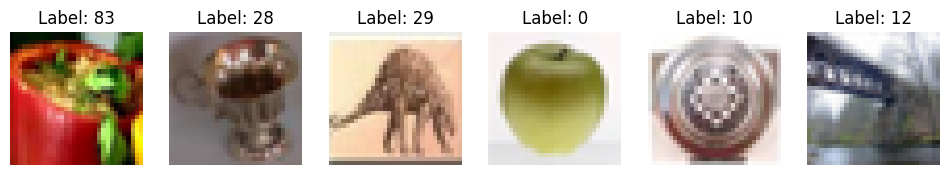

In [ ]:
def show_samples(loader, num=6):
    images, labels = next(iter(loader))
    images = images[:num]
    labels = labels[:num]
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3,1,1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3,1,1)
    images_vis = images * std + mean
    images_vis = images_vis.clamp(0,1)
    fig, axes = plt.subplots(1, num, figsize=(12,3))
    for i in range(num):
        axes[i].imshow(images_vis[i].permute(1,2,0).numpy())
        axes[i].axis('off')
        axes[i].set_title(f'Label: {labels[i].item()}')
    plt.show()

train_loader_base, _ = make_loaders(base_transform, base_transform)
show_samples(train_loader_base)

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))  # -> (128,1,1)
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == targets).sum().item()
        total += inputs.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += inputs.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
criterion = nn.CrossEntropyLoss()
num_epochs = 20
lr = 0.001
batch_size = 128

results = []

print("=== C1: SimpleCNN, no augmentations ===")
model_c1 = SimpleCNN(num_classes=100).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=lr)
train_loader_c1, val_loader_c1 = make_loaders(base_transform, base_transform, batch_size)
best_val_acc = 0.0
for epoch in range(1, num_epochs+1):
    train_loss, train_acc = train_one_epoch(model_c1, train_loader_c1, criterion, optimizer_c1, device)
    val_loss, val_acc = evaluate(model_c1, val_loader_c1, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_c1.state_dict(), 'artifacts/best_c1.pt')
    print(f"Epoch {epoch}: train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

test_loss, test_acc = evaluate(model_c1, test_loader, criterion, device)
results.append({
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': SEED,
    'model_summary': 'SimpleCNN (no aug)',
    'optimizer': 'Adam',
    'lr': lr,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': ''
})

=== C1: SimpleCNN, no augmentations ===
Epoch 1: train_loss=4.1650 acc=0.0604 | val_loss=3.8651 acc=0.1023
Epoch 2: train_loss=3.7052 acc=0.1264 | val_loss=3.5936 acc=0.1504
Epoch 3: train_loss=3.4582 acc=0.1668 | val_loss=3.3616 acc=0.1942
Epoch 4: train_loss=3.3003 acc=0.2010 | val_loss=3.2541 acc=0.2175
Epoch 5: train_loss=3.1648 acc=0.2276 | val_loss=3.1258 acc=0.2405
Epoch 6: train_loss=3.0307 acc=0.2565 | val_loss=3.0190 acc=0.2557
Epoch 7: train_loss=2.9107 acc=0.2774 | val_loss=2.9022 acc=0.2859
Epoch 8: train_loss=2.8038 acc=0.2996 | val_loss=2.8275 acc=0.2950
Epoch 9: train_loss=2.7196 acc=0.3182 | val_loss=2.7717 acc=0.3102
Epoch 10: train_loss=2.6435 acc=0.3298 | val_loss=2.6884 acc=0.3226
Epoch 11: train_loss=2.5813 acc=0.3434 | val_loss=2.6377 acc=0.3320
Epoch 12: train_loss=2.5174 acc=0.3586 | val_loss=2.6290 acc=0.3331
Epoch 13: train_loss=2.4702 acc=0.3693 | val_loss=2.5713 acc=0.3489
Epoch 14: train_loss=2.4231 acc=0.3799 | val_loss=2.5326 acc=0.3584
Epoch 15: train_l

In [ ]:
print("=== C2: SimpleCNN with augmentations ===")
model_c2 = SimpleCNN(num_classes=100).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=lr)
train_loader_c2, val_loader_c2 = make_loaders(aug_transform, base_transform, batch_size)
best_val_acc = 0.0
for epoch in range(1, num_epochs+1):
    train_loss, train_acc = train_one_epoch(model_c2, train_loader_c2, criterion, optimizer_c2, device)
    val_loss, val_acc = evaluate(model_c2, val_loader_c2, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_c2.state_dict(), 'artifacts/best_c2.pt')
    print(f"Epoch {epoch}: train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")
test_loss, test_acc = evaluate(model_c2, test_loader, criterion, device)
results.append({
    'experiment_id': 'C2',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': SEED,
    'model_summary': 'SimpleCNN (with aug)',
    'optimizer': 'Adam',
    'lr': lr,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': ''
})

=== C2: SimpleCNN with augmentations ===
Epoch 1: train_loss=4.1652 acc=0.0638 | val_loss=3.9119 acc=0.1007
Epoch 2: train_loss=3.7015 acc=0.1267 | val_loss=3.5333 acc=0.1582
Epoch 3: train_loss=3.4200 acc=0.1782 | val_loss=3.3540 acc=0.1967
Epoch 4: train_loss=3.2364 acc=0.2140 | val_loss=3.2015 acc=0.2272
Epoch 5: train_loss=3.0894 acc=0.2435 | val_loss=3.0564 acc=0.2507
Epoch 6: train_loss=2.9656 acc=0.2643 | val_loss=2.9625 acc=0.2724
Epoch 7: train_loss=2.8551 acc=0.2863 | val_loss=2.9146 acc=0.2838
Epoch 8: train_loss=2.7646 acc=0.3040 | val_loss=2.8062 acc=0.3029
Epoch 9: train_loss=2.6890 acc=0.3222 | val_loss=2.7430 acc=0.3128
Epoch 10: train_loss=2.6125 acc=0.3392 | val_loss=2.7197 acc=0.3218
Epoch 11: train_loss=2.5475 acc=0.3505 | val_loss=2.6433 acc=0.3366
Epoch 12: train_loss=2.4865 acc=0.3623 | val_loss=2.5860 acc=0.3493
Epoch 13: train_loss=2.4376 acc=0.3727 | val_loss=2.5735 acc=0.3445
Epoch 14: train_loss=2.3860 acc=0.3853 | val_loss=2.5309 acc=0.3583
Epoch 15: train_

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

print("=== C3: ResNet18 head-only ===")
model_c3 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

for param in model_c3.parameters():
    param.requires_grad = False
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 100)
model_c3 = model_c3.to(device)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=lr)

def make_resnet_loaders(batch_size=64):
    train_dataset = Subset(full_train, train_subset.indices)
    val_dataset = Subset(full_train, val_subset.indices)
    train_dataset.dataset.transform = resize_transform
    val_dataset.dataset.transform = resize_transform
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader

train_loader_c3, val_loader_c3 = make_resnet_loaders(batch_size=64)
test_dataset_resize = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=resize_transform
)
test_loader_c3 = DataLoader(test_dataset_resize, batch_size=64, shuffle=False)

# Обучение
best_val_acc = 0.0
for epoch in range(1, num_epochs+1):
    train_loss, train_acc = train_one_epoch(model_c3, train_loader_c3, criterion, optimizer_c3, device)
    val_loss, val_acc = evaluate(model_c3, val_loader_c3, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_c3.state_dict(), 'artifacts/best_c3.pt')
    print(f"Epoch {epoch}: train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")
test_loss, test_acc = evaluate(model_c3, test_loader_c3, criterion, device)
results.append({
    'experiment_id': 'C3',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': SEED,
    'model_summary': 'ResNet18 с замороженным backbone',
    'optimizer': 'Adam',
    'lr': lr,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': ''
})

=== C3: ResNet18 head-only ===
Epoch 1: train_loss=2.5186 acc=0.4035 | val_loss=1.8213 acc=0.5163
Epoch 2: train_loss=1.6674 acc=0.5541 | val_loss=1.6350 acc=0.5569
Epoch 3: train_loss=1.5019 acc=0.5884 | val_loss=1.5603 acc=0.5695
Epoch 4: train_loss=1.4183 acc=0.6063 | val_loss=1.5288 acc=0.5748
Epoch 5: train_loss=1.3554 acc=0.6210 | val_loss=1.5452 acc=0.5745
Epoch 6: train_loss=1.3144 acc=0.6317 | val_loss=1.5065 acc=0.5815
Epoch 7: train_loss=1.2809 acc=0.6411 | val_loss=1.5246 acc=0.5766
Epoch 8: train_loss=1.2489 acc=0.6472 | val_loss=1.5154 acc=0.5823
Epoch 9: train_loss=1.2222 acc=0.6577 | val_loss=1.5340 acc=0.5766
Epoch 10: train_loss=1.2045 acc=0.6556 | val_loss=1.5352 acc=0.5794
Epoch 11: train_loss=1.1872 acc=0.6620 | val_loss=1.5770 acc=0.5712
Epoch 12: train_loss=1.1778 acc=0.6647 | val_loss=1.5489 acc=0.5823
Epoch 13: train_loss=1.1594 acc=0.6672 | val_loss=1.5507 acc=0.5788
Epoch 14: train_loss=1.1504 acc=0.6711 | val_loss=1.5467 acc=0.5793
Epoch 15: train_loss=1.133

In [ ]:
print("=== C4: ResNet18 fine-tune (layer4 + fc) ===")
model_c4 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

for param in model_c4.parameters():
    param.requires_grad = False

for param in model_c4.layer4.parameters():
    param.requires_grad = True
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, 100)
model_c4 = model_c4.to(device)

optimizer_c4 = optim.Adam(list(model_c4.layer4.parameters()) + list(model_c4.fc.parameters()), lr=lr)

train_loader_c4, val_loader_c4 = make_resnet_loaders(batch_size=64)
best_val_acc = 0.0
for epoch in range(1, num_epochs+1):
    train_loss, train_acc = train_one_epoch(model_c4, train_loader_c4, criterion, optimizer_c4, device)
    val_loss, val_acc = evaluate(model_c4, val_loader_c4, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_c4.state_dict(), 'artifacts/best_c4.pt')
    print(f"Epoch {epoch}: train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")
test_loss, test_acc = evaluate(model_c4, test_loader_c3, criterion, device)
results.append({
    'experiment_id': 'C4',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': SEED,
    'model_summary': 'ResNet18 fine-tune (разморожен последний блок и fc)',
    'optimizer': 'Adam',
    'lr': lr,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': ''
})

=== C4: ResNet18 fine-tune (layer4 + fc) ===
Epoch 1: train_loss=1.7316 acc=0.5200 | val_loss=1.2939 acc=0.6290
Epoch 2: train_loss=0.9433 acc=0.7175 | val_loss=1.2850 acc=0.6374
Epoch 3: train_loss=0.5484 acc=0.8295 | val_loss=1.3089 acc=0.6519
Epoch 4: train_loss=0.2897 acc=0.9075 | val_loss=1.4699 acc=0.6443
Epoch 5: train_loss=0.1804 acc=0.9430 | val_loss=1.5191 acc=0.6565
Epoch 6: train_loss=0.1435 acc=0.9549 | val_loss=1.5952 acc=0.6527
Epoch 7: train_loss=0.1407 acc=0.9556 | val_loss=1.7190 acc=0.6493
Epoch 8: train_loss=0.1164 acc=0.9625 | val_loss=1.7580 acc=0.6507
Epoch 9: train_loss=0.1033 acc=0.9679 | val_loss=1.8447 acc=0.6544
Epoch 10: train_loss=0.0885 acc=0.9718 | val_loss=1.9084 acc=0.6506
Epoch 11: train_loss=0.0884 acc=0.9720 | val_loss=1.9479 acc=0.6546
Epoch 12: train_loss=0.0893 acc=0.9707 | val_loss=2.1139 acc=0.6475
Epoch 13: train_loss=0.0908 acc=0.9716 | val_loss=2.0111 acc=0.6552
Epoch 14: train_loss=0.0699 acc=0.9777 | val_loss=2.1330 acc=0.6529
Epoch 15: tr

In [ ]:
best_model_id = max(results, key=lambda x: x['best_val_accuracy'])['experiment_id']
print(f"Лучшая модель: {best_model_id} с val_accuracy = {max(r['best_val_accuracy'] for r in results):.4f}")


if best_model_id == 'C1':
    best_model = SimpleCNN(num_classes=100).to(device)
    best_model.load_state_dict(torch.load('artifacts/best_c1.pt'))
    config = {'architecture': 'SimpleCNN', 'augmentations': False, 'pretrained': False}
elif best_model_id == 'C2':
    best_model = SimpleCNN(num_classes=100).to(device)
    best_model.load_state_dict(torch.load('artifacts/best_c2.pt'))
    config = {'architecture': 'SimpleCNN', 'augmentations': True, 'pretrained': False}
elif best_model_id == 'C3':
    best_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    best_model.fc = nn.Linear(512, 100)
    best_model.load_state_dict(torch.load('artifacts/best_c3.pt'))
    best_model = best_model.to(device)
    config = {'architecture': 'ResNet18', 'augmentations': False, 'pretrained': True, 'head_only': True}
else:
    best_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    best_model.fc = nn.Linear(512, 100)
    best_model.load_state_dict(torch.load('artifacts/best_c4.pt'))
    best_model = best_model.to(device)
    config = {'architecture': 'ResNet18', 'augmentations': False, 'pretrained': True, 'fine_tune': 'layer4+fc'}


with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)


torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

Лучшая модель: C4 с val_accuracy = 0.6669


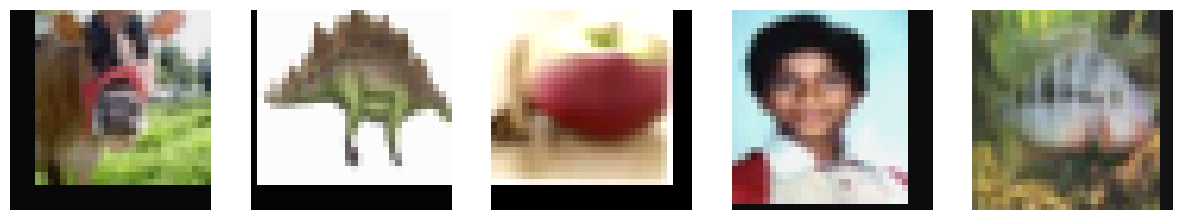

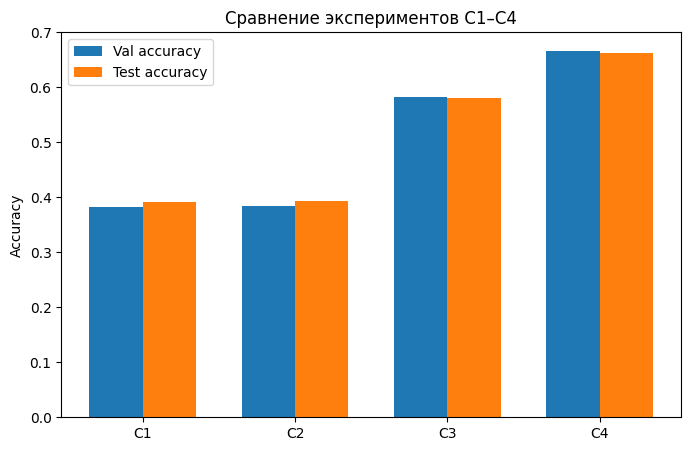

In [ ]:
def show_augmentations(transform, num_images=5):
    dataset = torchvision.datasets.CIFAR100(root='./data', train=True, transform=transform)
    fig, axes = plt.subplots(1, num_images, figsize=(15,3))
    for i in range(num_images):
        img, _ = dataset[i]
        mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3,1,1)
        std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3,1,1)
        img_vis = img * std + mean
        img_vis = img_vis.clamp(0,1)
        axes[i].imshow(img_vis.permute(1,2,0).numpy())
        axes[i].axis('off')
    plt.savefig('artifacts/figures/augmentations_preview.png', dpi=100, bbox_inches='tight')
    plt.show()

os.makedirs('artifacts/figures', exist_ok=True)
show_augmentations(aug_transform)

val_accs = [r['best_val_accuracy'] for r in results]
test_accs = [r['test_accuracy'] for r in results]
ids = [r['experiment_id'] for r in results]

plt.figure(figsize=(8,5))
x = np.arange(len(ids))
width = 0.35
plt.bar(x - width/2, val_accs, width, label='Val accuracy')
plt.bar(x + width/2, test_accs, width, label='Test accuracy')
plt.xticks(x, ids)
plt.ylabel('Accuracy')
plt.title('Сравнение экспериментов C1–C4')
plt.legend()
plt.savefig('artifacts/figures/classification_compare.png', dpi=100, bbox_inches='tight')
plt.show()

Построение кривых обучения для лучшей модели: C4
Epoch 1: train_loss=1.7348 acc=0.5218 | val_loss=1.3337 acc=0.6123
Epoch 2: train_loss=0.9636 acc=0.7146 | val_loss=1.2154 acc=0.6557
Epoch 3: train_loss=0.5445 acc=0.8294 | val_loss=1.2654 acc=0.6600
Epoch 4: train_loss=0.2973 acc=0.9040 | val_loss=1.4070 acc=0.6534
Epoch 5: train_loss=0.1786 acc=0.9431 | val_loss=1.5674 acc=0.6475
Epoch 6: train_loss=0.1476 acc=0.9524 | val_loss=1.5857 acc=0.6581
Epoch 7: train_loss=0.1289 acc=0.9597 | val_loss=1.7018 acc=0.6572
Epoch 8: train_loss=0.1210 acc=0.9609 | val_loss=1.6875 acc=0.6597
Epoch 9: train_loss=0.1020 acc=0.9679 | val_loss=1.8467 acc=0.6419
Epoch 10: train_loss=0.0913 acc=0.9708 | val_loss=1.9851 acc=0.6400
Epoch 11: train_loss=0.0877 acc=0.9730 | val_loss=1.8707 acc=0.6570
Epoch 12: train_loss=0.0931 acc=0.9706 | val_loss=1.9723 acc=0.6443
Epoch 13: train_loss=0.0708 acc=0.9766 | val_loss=2.0173 acc=0.6544
Epoch 14: train_loss=0.0685 acc=0.9789 | val_loss=2.0307 acc=0.6528
Epoch 15

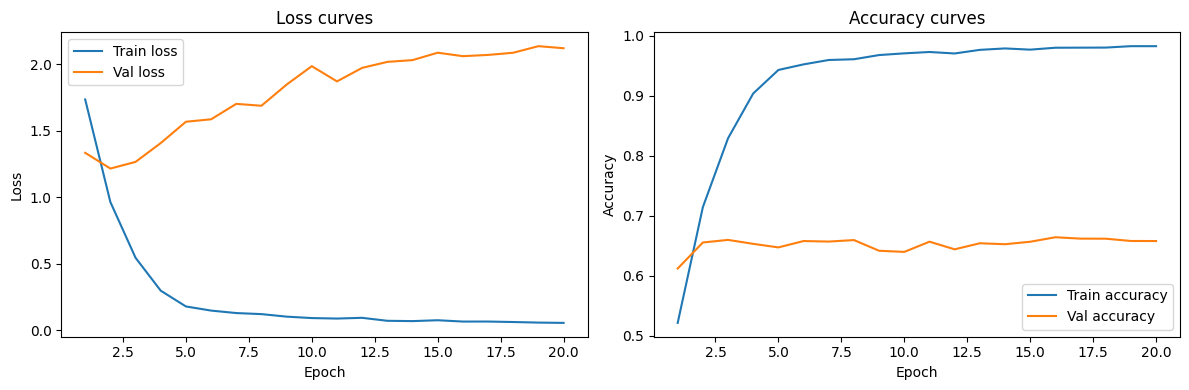

In [ ]:
print(f"Построение кривых обучения для лучшей модели: {best_model_id}")

if best_model_id == 'C1':
    model_best = SimpleCNN(num_classes=100).to(device)
    optimizer_best = optim.Adam(model_best.parameters(), lr=lr)
    train_loader_best, val_loader_best = make_loaders(base_transform, base_transform, batch_size)
    test_loader_best = test_loader
    epochs = num_epochs
elif best_model_id == 'C2':
    model_best = SimpleCNN(num_classes=100).to(device)
    optimizer_best = optim.Adam(model_best.parameters(), lr=lr)
    train_loader_best, val_loader_best = make_loaders(aug_transform, base_transform, batch_size)
    test_loader_best = test_loader
    epochs = num_epochs
elif best_model_id == 'C3':
    model_best = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in model_best.parameters():
        param.requires_grad = False
    num_ftrs = model_best.fc.in_features
    model_best.fc = nn.Linear(num_ftrs, 100)
    model_best = model_best.to(device)
    optimizer_best = optim.Adam(model_best.fc.parameters(), lr=lr)
    train_loader_best, val_loader_best = make_resnet_loaders(batch_size=64)
    test_loader_best = test_loader_c3
    epochs = num_epochs
else:
    model_best = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in model_best.parameters():
        param.requires_grad = False
    for param in model_best.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model_best.fc.in_features
    model_best.fc = nn.Linear(num_ftrs, 100)
    model_best = model_best.to(device)
    optimizer_best = optim.Adam(list(model_best.layer4.parameters()) + list(model_best.fc.parameters()), lr=lr)
    train_loader_best, val_loader_best = make_resnet_loaders(batch_size=64)
    test_loader_best = test_loader_c3
    epochs = num_epochs

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, epochs+1):
    train_loss, train_acc = train_one_epoch(model_best, train_loader_best, criterion, optimizer_best, device)
    val_loss, val_acc = evaluate(model_best, val_loader_best, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, label='Train loss')
plt.plot(range(1, epochs+1), val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accs, label='Train accuracy')
plt.plot(range(1, epochs+1), val_accs, label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curves')

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=100, bbox_inches='tight')
plt.show()

# Часть B (S11)

In [ ]:
voc_train = torchvision.datasets.VOCDetection(
    root='./data', year='2012', image_set='train', download=True
)
voc_val = torchvision.datasets.VOCDetection(
    root='./data', year='2012', image_set='val', download=True
)

image, target = voc_train[0]
print(target)

100.0%


{'annotation': {'folder': 'VOC2012', 'filename': '2008_000008.jpg', 'source': {'database': 'The VOC2008 Database', 'annotation': 'PASCAL VOC2008', 'image': 'flickr'}, 'size': {'width': '500', 'height': '442', 'depth': '3'}, 'segmented': '0', 'object': [{'name': 'horse', 'pose': 'Left', 'truncated': '0', 'occluded': '1', 'bndbox': {'xmin': '53', 'ymin': '87', 'xmax': '471', 'ymax': '420'}, 'difficult': '0'}, {'name': 'person', 'pose': 'Unspecified', 'truncated': '1', 'occluded': '0', 'bndbox': {'xmin': '158', 'ymin': '44', 'xmax': '289', 'ymax': '167'}, 'difficult': '0'}]}}


In [19]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

model_det = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
model_det = model_det.to(device)
model_det.eval()

0.2%

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\098ja/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def match_predictions(gt_boxes, pred_boxes, pred_scores, iou_thresh=0.5, score_thresh=0.3):
    keep = pred_scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]
    
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0, 0, 0
    
    matches = []
    for i, gt in enumerate(gt_boxes):
        best_iou = 0
        best_j = -1
        for j, pred in enumerate(pred_boxes):
            iou = compute_iou(gt, pred)
            if iou > best_iou and iou >= iou_thresh:
                best_iou = iou
                best_j = j
        if best_j != -1:
            matches.append((i, best_j, best_iou))
            

    used_pred = set()
    tp = 0
    for _, pred_idx, _ in matches:
        if pred_idx not in used_pred:
            used_pred.add(pred_idx)
            tp += 1
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp
    return tp, fp, fn

def compute_metrics_for_loader(model, loader, score_thresh, device):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_iou = 0.0
    total_matches = 0
    
    model.eval()
    with torch.no_grad():
        for images, targets in loader:
            images = [T.ToTensor()(img).to(device) for img in images]
            outputs = model(images)
            for i in range(len(images)):
                pred = outputs[i]
                pred_boxes = pred['boxes'].cpu().numpy()
                pred_scores = pred['scores'].cpu().numpy()
                gt_boxes = []
                ann = targets[i]['annotation']
                obj = ann['object']
                if not isinstance(obj, list):
                    obj = [obj]
                for o in obj:
                    bbox = o['bndbox']
                    x1 = float(bbox['xmin'])
                    y1 = float(bbox['ymin'])
                    x2 = float(bbox['xmax'])
                    y2 = float(bbox['ymax'])
                    gt_boxes.append([x1, y1, x2, y2])
                gt_boxes = np.array(gt_boxes)
                tp, fp, fn = match_predictions(gt_boxes, pred_boxes, pred_scores, 
                                               iou_thresh=0.5, score_thresh=score_thresh)
                total_tp += tp
                total_fp += fp
                total_fn += fn
                if tp > 0:
                    iou_val = compute_mean_iou_for_sample(gt_boxes, pred_boxes, pred_scores, score_thresh)
                    total_iou += iou_val
                    total_matches += 1
    precision = total_tp / (total_tp + total_fp) if (total_tp+total_fp)>0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp+total_fn)>0 else 0
    mean_iou = total_iou / total_matches if total_matches>0 else 0
    return precision, recall, mean_iou

def compute_mean_iou_for_sample(gt_boxes, pred_boxes, pred_scores, score_thresh):
    keep = pred_scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    if len(pred_boxes)==0 or len(gt_boxes)==0:
        return 0.0
    matches = []
    used_pred = set()
    for i, gt in enumerate(gt_boxes):
        best_iou = 0
        best_j = -1
        for j, pred in enumerate(pred_boxes):
            iou = compute_iou(gt, pred)
            if iou > best_iou and iou >= 0.5:
                best_iou = iou
                best_j = j
        if best_j != -1 and best_j not in used_pred:
            used_pred.add(best_j)
            matches.append((i, best_j, best_iou))
    if matches:
        return np.mean([iou for _,_,iou in matches])
    else:
        return 0.0

In [ ]:
class VOCDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, voc_dataset):
        self.voc = voc_dataset
    def __len__(self):
        return len(self.voc)
    def __getitem__(self, idx):
        img, target = self.voc[idx]
        return img, target

val_dataset = VOCDatasetWrapper(voc_val)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# V1: порог 0.3
precision1, recall1, miou1 = compute_metrics_for_loader(model_det, val_loader, score_thresh=0.3, device=device)
print(f"V1 (thresh=0.3): Precision={precision1:.4f}, Recall={recall1:.4f}, mean IoU={miou1:.4f}")

# V2: порог 0.7
precision2, recall2, miou2 = compute_metrics_for_loader(model_det, val_loader, score_thresh=0.7, device=device)
print(f"V2 (thresh=0.7): Precision={precision2:.4f}, Recall={recall2:.4f}, mean IoU={miou2:.4f}")

V1 (thresh=0.3): Precision=0.2985, Recall=0.8931, mean IoU=0.8397
V2 (thresh=0.7): Precision=0.5681, Recall=0.8120, mean IoU=0.8396


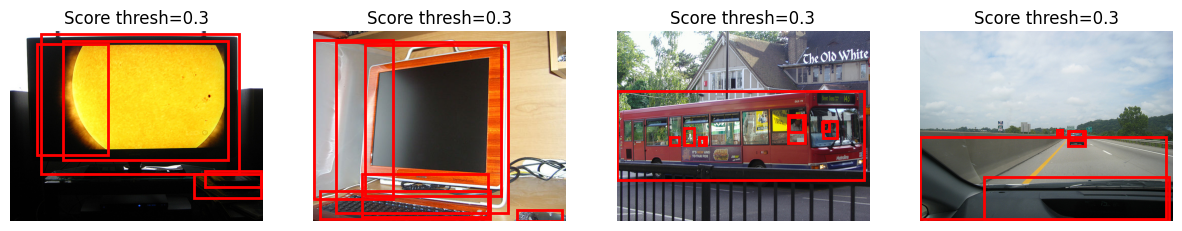

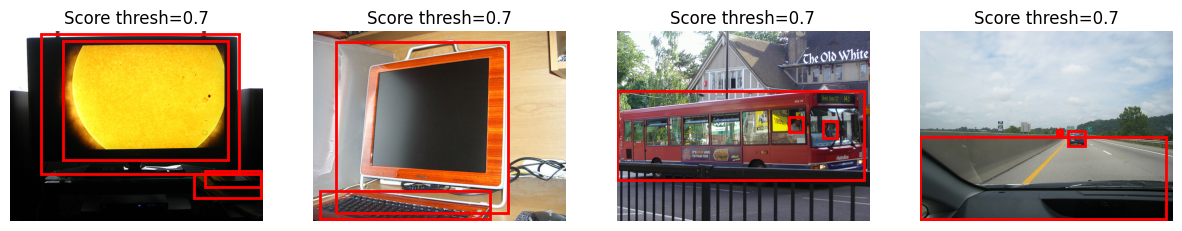

In [ ]:
def visualize_predictions(model, loader, score_thresh, num_images=4, save_path=None):
    model.eval()
    fig, axes = plt.subplots(1, num_images, figsize=(15,5))
    with torch.no_grad():
        for i, (images, targets) in enumerate(loader):
            if i >= num_images:
                break
            img_tensor = T.ToTensor()(images[0]).to(device)
            out = model([img_tensor])[0]
            img_np = np.array(images[0])
            axes[i].imshow(img_np)
            boxes = out['boxes'].cpu().numpy()
            scores = out['scores'].cpu().numpy()
            keep = scores >= score_thresh
            boxes = boxes[keep]
            for box in boxes:
                x1,y1,x2,y2 = box
                rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
                axes[i].add_patch(rect)
            axes[i].axis('off')
            axes[i].set_title(f'Score thresh={score_thresh}')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

visualize_predictions(model_det, val_loader, score_thresh=0.3, num_images=4,
                      save_path='artifacts/figures/detection_examples_thresh0.3.png')
visualize_predictions(model_det, val_loader, score_thresh=0.7, num_images=4,
                      save_path='artifacts/figures/detection_examples_thresh0.7.png')

Загружено из CSV: V1: P=0.2985, R=0.8931, mIoU=0.8397
V2: P=0.5681, R=0.8120, mIoU=0.8396


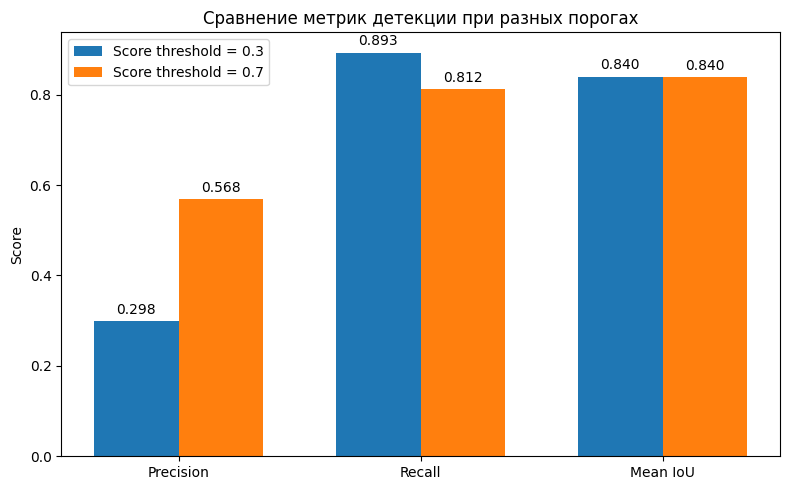

Сохранено detection_metrics.png


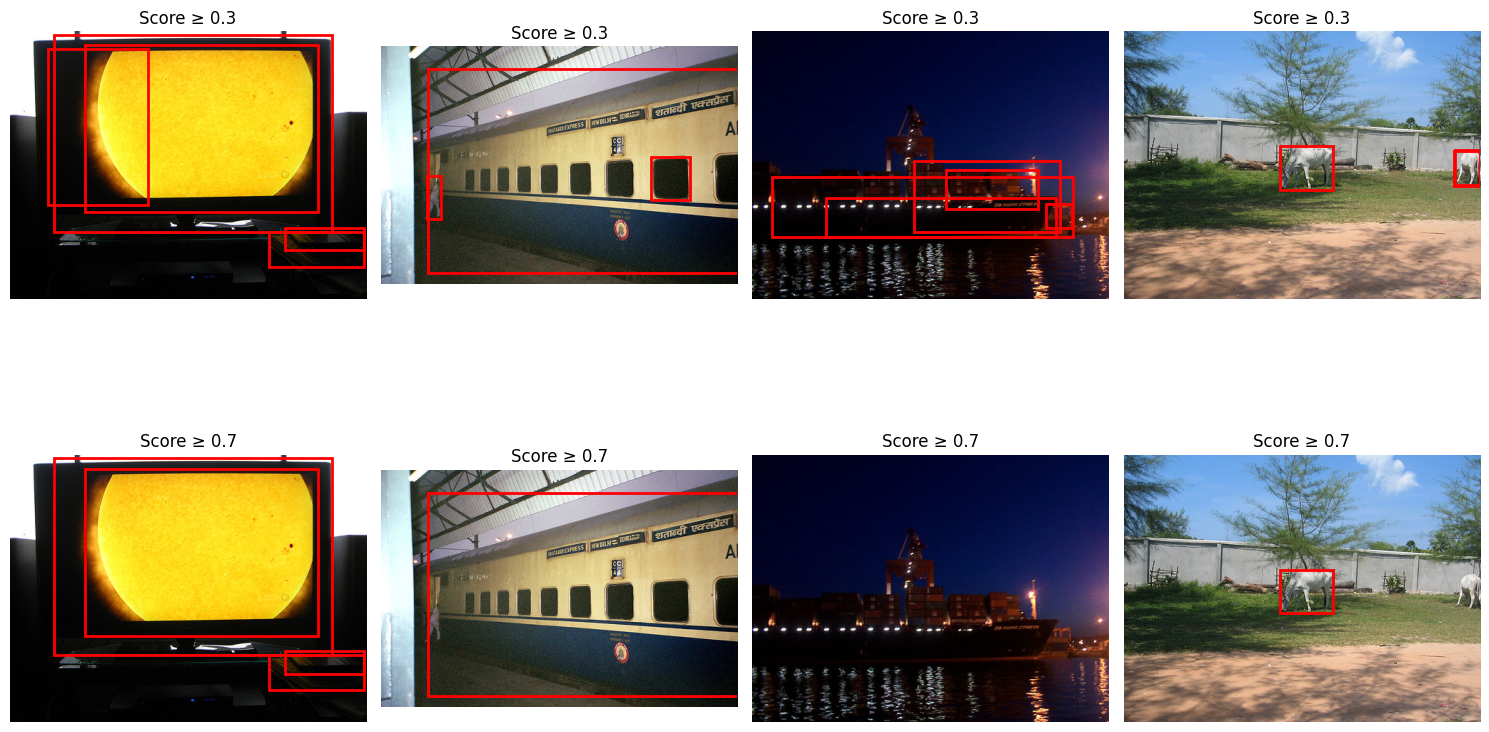

Сохранено detection_examples.png


In [ ]:
os.makedirs('artifacts/figures', exist_ok=True)

metrics = ['Precision', 'Recall', 'Mean IoU']
values_v1 = [precision1, recall1, miou1]
values_v2 = [precision2, recall2, miou2]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, values_v1, width, label='Score threshold = 0.3')
bars2 = ax.bar(x + width/2, values_v2, width, label='Score threshold = 0.7')

ax.set_ylabel('Score')
ax.set_title('Сравнение метрик детекции при разных порогах')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig('artifacts/figures/detection_metrics.png', dpi=100, bbox_inches='tight')
plt.show()
print("Сохранено detection_metrics.png")

num_images = 4
fig, axes = plt.subplots(2, num_images, figsize=(15, 10))

with torch.no_grad():
    for i, (images, targets) in enumerate(val_loader):
        if i >= num_images:
            break
        img = images[0]
        img_tensor = T.ToTensor()(img).to(device)
        out = model_det([img_tensor])[0]
        img_np = np.array(img)
        
        # Порог 0.3
        axes[0, i].imshow(img_np)
        boxes = out['boxes'].cpu().numpy()
        scores = out['scores'].cpu().numpy()
        keep = scores >= 0.3
        for box in boxes[keep]:
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
            axes[0, i].add_patch(rect)
        axes[0, i].axis('off')
        axes[0, i].set_title('Score ≥ 0.3')
        
        # Порог 0.7
        axes[1, i].imshow(img_np)
        keep = scores >= 0.7
        for box in boxes[keep]:
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
            axes[1, i].add_patch(rect)
        axes[1, i].axis('off')
        axes[1, i].set_title('Score ≥ 0.7')

plt.tight_layout()
plt.savefig('artifacts/figures/detection_examples.png', dpi=100, bbox_inches='tight')
plt.show()
print("Сохранено detection_examples.png")

In [ ]:
results.append({
    'experiment_id': 'V1',
    'task': 'detection',
    'dataset': 'PascalVOC2012',
    'seed': SEED,
    'model_summary': 'FasterRCNN_ResNet50_FPN',
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': precision1,
    'recall': recall1,
    'mean_iou': miou1,
    'notes': 'score_threshold=0.3'
})
results.append({
    'experiment_id': 'V2',
    'task': 'detection',
    'dataset': 'PascalVOC2012',
    'seed': SEED,
    'model_summary': 'FasterRCNN_ResNet50_FPN',
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': precision2,
    'recall': recall2,
    'mean_iou': miou2,
    'notes': 'score_threshold=0.7'
})

df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)